#  Load and Explore the Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the built-in Auto MPG dataset. Uses the classic Auto MPG dataset bundled with the seaborn library
df = sns.load_dataset('mpg')

# A few rows have a missing 'horsepower' value - drop them
df = df.dropna(subset=['horsepower', 'mpg'])

print(df.shape)
print(df[['horsepower', 'weight', 'mpg']].head())


(392, 9)
   horsepower  weight   mpg
0       130.0    3504  18.0
1       165.0    3693  15.0
2       150.0    3436  18.0
3       150.0    3433  16.0
4       140.0    3449  17.0


# Visualise horsepower against mpg

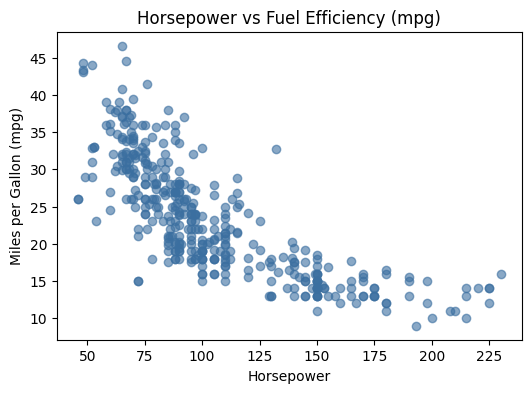

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, color='#3b6fa0')
plt.title('Horsepower vs Fuel Efficiency (mpg)')
plt.xlabel('Horsepower')
plt.ylabel('Miles per Gallon (mpg)')
plt.show()


# Baseline — Simple Linear Regression
Before reaching for polynomial regression, fit an ordinary straight-line model, so we have something to compare against.

Linear R2: 0.5659681822256185


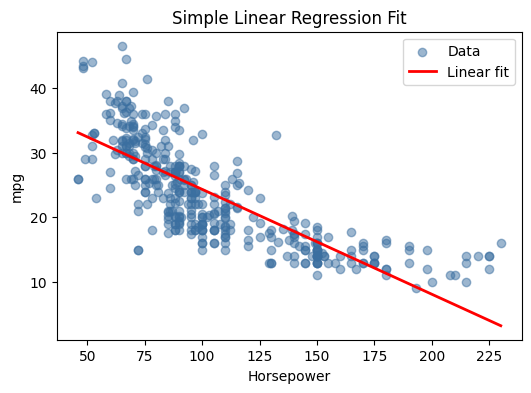

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['horsepower']].values
y = df['mpg'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('Linear R2:', r2_score(y_test, y_pred))

# Plot the fitted line to see why it struggles
order = np.argsort(X_train[:, 0])

plt.figure(figsize=(6,4))
plt.scatter(X, y, alpha=0.5, color='#3b6fa0', label='Data')

plt.plot(X_train[order], lr.predict(X_train)[order],
         color='red', linewidth=2, label='Linear fit')
plt.title('Simple Linear Regression Fit')
plt.xlabel('Horsepower'); plt.ylabel('mpg'); plt.legend()
plt.show()




# Apply Polynomial Regression (degree 2)
Polynomial regression is still “linear regression” — the trick is that we first transform the input into polynomial terms (x, x², ...) with PolynomialFeatures, and then fit an ordinary LinearRegression on those transformed features.

Polynomial (degree 2) R2: 0.6391701147013347
Coefficients: [ 0.         -0.48445839  0.0012949 ]
Intercept: 58.212944359179374


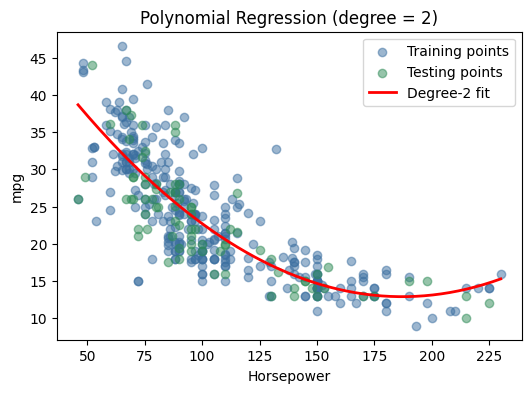

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

print('Polynomial (degree 2) R2:', r2_score(y_test, y_pred_poly))
print('Coefficients:', lr_poly.coef_)
print('Intercept:', lr_poly.intercept_)

# visualise the curved fit across the full range of horsepower

X_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = lr_poly.predict(X_range_poly)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, alpha=0.5, color='#3b6fa0', label='Training points')
plt.scatter(X_test, y_test, alpha=0.5, color='#2e8b57', label='Testing points')
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Degree-2 fit')
plt.title('Polynomial Regression (degree = 2)')
plt.xlabel('Horsepower'); plt.ylabel('mpg'); plt.legend()
plt.show()


# Choosing the Right Degree
Higher degrees are not automatically better. A degree that is too low underfits (misses the curve); a degree that is too high overfits (chases noise in the training data and wiggles wildly). We wrap the steps in a Pipeline so we can try several degrees quickly.

degree 1: R2 = 0.5660
degree 2: R2 = 0.6392
degree 15: R2 = 0.6333


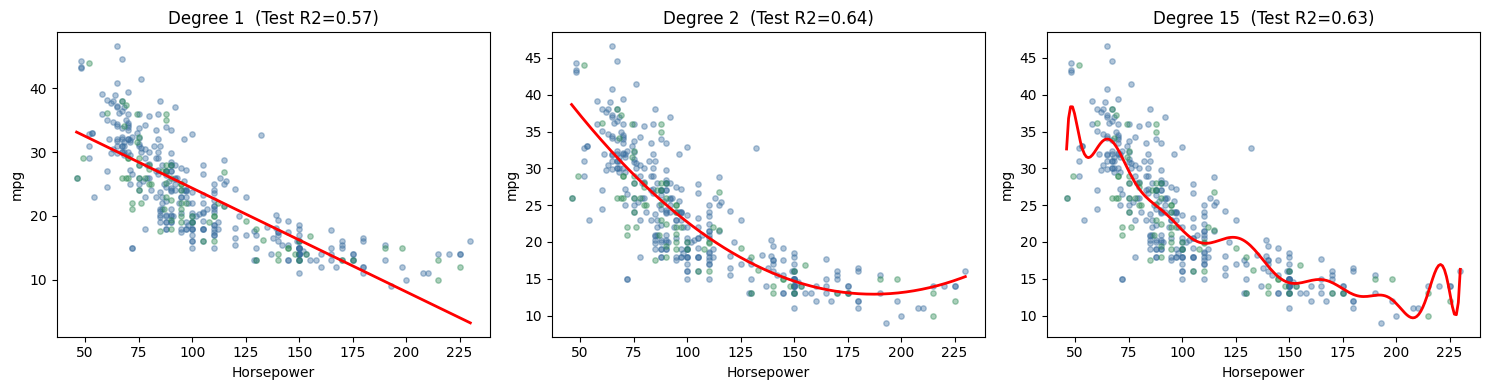

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def polynomial_regression(degree, ax):
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('std_scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])
    model.fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))

    X_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_range_pred = model.predict(X_range)

    ax.scatter(X_train, y_train, alpha=0.4, color='#3b6fa0', s=15)
    ax.scatter(X_test, y_test, alpha=0.4, color='#2e8b57', s=15)
    ax.plot(X_range, y_range_pred, color='red', linewidth=2)
    ax.set_title(f'Degree {degree}  (Test R2={r2:.2f})')
    ax.set_xlabel('Horsepower'); ax.set_ylabel('mpg')
    return r2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d in zip(axes, [1, 2, 15]):
    r2 = polynomial_regression(d, ax)
    print(f'degree {d}: R2 = {r2:.4f}')

plt.tight_layout()
plt.show()


# Polynomial Regression with Multiple Features (3D)
Real datasets usually have more than one useful input feature. Here we use both horsepower and weight to predict mpg, and visualise the fitted surface in 3D.

**Step 1) Visualise the raw data in 3D**

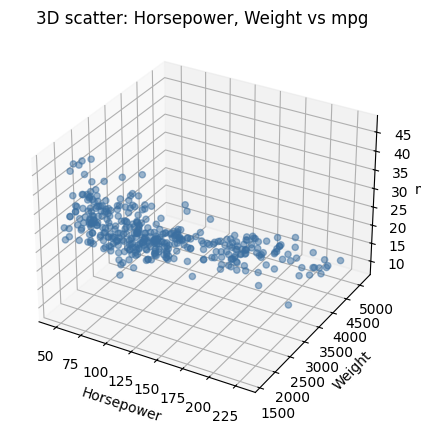

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

X_multi = df[['horsepower', 'weight']].values
y_multi = df['mpg'].values

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_multi[:,0], X_multi[:,1], y_multi, alpha=0.5, color='#3b6fa0')
ax.set_xlabel('Horsepower'); ax.set_ylabel('Weight'); ax.set_zlabel('mpg')
ax.set_title('3D scatter: Horsepower, Weight vs mpg')
plt.show()


**Step 2) Fit a degree-2 polynomial model on both features and plot the fitted surface**

3D Polynomial (degree 2) R2: 0.6883062442247381
Number of polynomial terms: 6


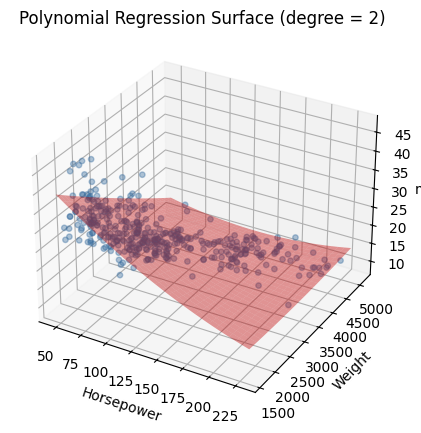

In [ ]:
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42)

poly2 = PolynomialFeatures(degree=2, include_bias=True)
Xm_train_poly = poly2.fit_transform(Xm_train)
Xm_test_poly = poly2.transform(Xm_test)

lr_multi = LinearRegression()
lr_multi.fit(Xm_train_poly, ym_train)
ym_pred = lr_multi.predict(Xm_test_poly)

print('3D Polynomial (degree 2) R2:', r2_score(ym_test, ym_pred))
print('Number of polynomial terms:', Xm_train_poly.shape[1])

# Build a grid over horsepower & weight to draw the fitted surface
hp_range = np.linspace(X_multi[:,0].min(), X_multi[:,0].max(), 30)
wt_range = np.linspace(X_multi[:,1].min(), X_multi[:,1].max(), 30)
hp_grid, wt_grid = np.meshgrid(hp_range, wt_range)
grid_poly = poly2.transform(
    np.column_stack([hp_grid.ravel(), wt_grid.ravel()]))
mpg_grid = lr_multi.predict(grid_poly).reshape(hp_grid.shape)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_multi[:,0], X_multi[:,1], y_multi,
           alpha=0.4, color='#3b6fa0', s=15, label='Data')
ax.plot_surface(hp_grid, wt_grid, mpg_grid, color='red', alpha=0.4)
ax.set_xlabel('Horsepower'); ax.set_ylabel('Weight'); ax.set_zlabel('mpg')
ax.set_title('Polynomial Regression Surface (degree = 2)')
plt.show()
